# Sales Prediction Using Linear Regression

## Project Overview

This project analyzes the relationship between **advertising expenditure and sales** and uses **Linear Regression** to predict sales based on advertising spend.

The project demonstrates an end-to-end machine learning workflow, including:

* Exploratory data analysis
* Understanding relationships between variables
* Train-test splitting
* Linear Regression model development
* Model evaluation using MAE, MSE, RMSE, and R²
* Interpretation of model coefficients
* Business-oriented prediction and insights

### Objective

To understand how changes in advertising expenditure are associated with sales and build a regression model that can estimate expected sales from a given advertising budget.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data ={
    'Advertising': [10,15,20,25,30,35,40,45,50],
    'Sales': [25,31,38,43,50,56,61,67,72]
}

df = pd.DataFrame(data)

## 1. Data Exploration

The dataset contains advertising expenditure and corresponding sales values.

Before building the model, we visualize the data to examine whether there is a relationship between advertising expenditure and sales.

### Key Question

**Does increased advertising expenditure correspond to increased sales?**


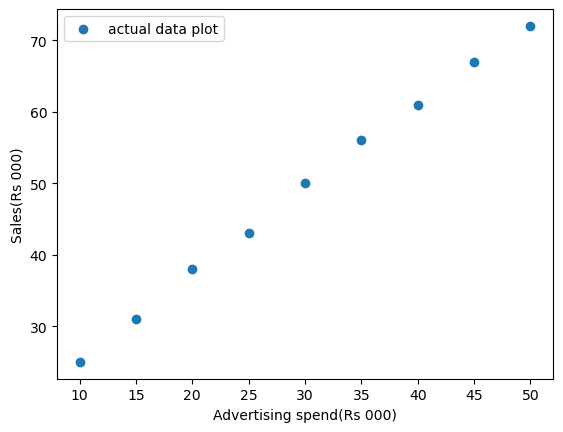

In [2]:
plt.scatter(df['Advertising'],df['Sales'],label='actual data plot')
plt.xlabel('Advertising spend(Rs 000)')
plt.ylabel('Sales(Rs 000)')
plt.legend()
plt.show()

### Observation

The scatter plot indicates a **positive relationship** between advertising expenditure and sales: higher advertising expenditure is generally associated with higher sales.

However, this observed relationship **does not by itself establish causation**. Other factors may also influence sales.


## 2. Model Preparation

### Feature and Target

* **Feature (X):** Advertising expenditure
* **Target (y):** Sales

The dataset is divided into:

* **80% training data**
* **20% testing data**

A `random_state` of 42 is used to make the train-test split reproducible.


In [3]:
from sklearn.model_selection import train_test_split

X = df[['Advertising']]  #2d
y = df['Sales']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 42)

## 3. Linear Regression Model

Linear Regression is used to model the relationship between advertising expenditure and sales.

The model follows the equation:

**Sales = β₀ + β₁ × Advertising**

where:

* **β₀** = intercept
* **β₁** = coefficient representing the change in predicted sales for a one-unit increase in advertising expenditure.


In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [5]:
print('Intercept: ',model.intercept_)
print('Coefficient: ',model.coef_[0])

Intercept:  14.000000000000014
Coefficient:  1.1761904761904758


### Model Coefficients

The trained model produces an intercept of approximately **14** and an advertising coefficient of approximately **1.176**.

This indicates that, within this dataset, an increase of one unit in advertising expenditure is associated with an estimated increase of approximately **1.176 units in sales**, according to the fitted linear model.

The coefficient represents an association within this dataset and should not be interpreted as proof that advertising alone causes the increase in sales.


## 4. Sales Prediction

The trained model can be used to estimate expected sales for a given advertising budget.

### Example

Suppose a company allocates an advertising budget corresponding to **40 units** in the dataset.

The trained regression model is used to estimate the expected sales value.


In [6]:
#=> y = coef*x + intercept
# y = b1*x +b0

#here b0 ~ 1.2
# => if advertising spend = 1000, sales = 1.2 *1000 = 1200->business interpretation

#if company wants to spend 40,000
#model prdicts:
prediction = model.predict(pd.DataFrame({'Advertising': [40]}))
print(prediction)

[61.04761905]


In [7]:
# -> sales predicted = 61000

In [8]:
#prediction on test data
y_pred= model.predict(X_test)

In [9]:
y_pred

array([66.92857143, 31.64285714])

## 5. Model Evaluation

The model is evaluated using multiple regression metrics:

### Mean Absolute Error (MAE)

Measures the average absolute difference between actual and predicted sales.

**MAE = 0.357**

### Mean Squared Error (MSE)

Measures the average squared prediction error and gives greater weight to larger errors.

**MSE = 0.209**

### Root Mean Squared Error (RMSE)

RMSE is the square root of MSE and is expressed in the same units as the target variable.

**RMSE = 0.457**

### R² Score

R² measures the proportion of variation in sales explained by the regression model.

**R² = 0.9994**


In [10]:
#MAE - mean absolute error
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test,y_pred)
print('MAE: ', mae)

MAE:  0.35714285714286653


In [11]:
# means on avg the model's prediction is off by 0.357

In [12]:
#MSE(mean square error) - penalizes large errors more heavily
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test,y_pred)
print('MSE: ',mse)

MSE:  0.20918367346939287


In [13]:
#model is off by 0.20

In [14]:
#RMSE- easir to interpret as in same unit as the target
import numpy as np

rmse = np.sqrt(mse)
print('RMSE: ',rmse)

RMSE:  0.4573660169594948


In [15]:
#model is off by 0.46

In [16]:
# R2
from sklearn.metrics import r2_score

r2 = r2_score(y_test,y_pred)
print('R2', r2)

R2 0.9993543713781808


In [17]:
#the model explains 99% of the variation in sales in this dataset

## Fitted Regression Line

The fitted regression line represents the linear relationship learned by the Linear Regression model between advertising expenditure and sales.

The line is fitted using the training data and can be used to visualize how the model's predictions compare with the observed sales values.

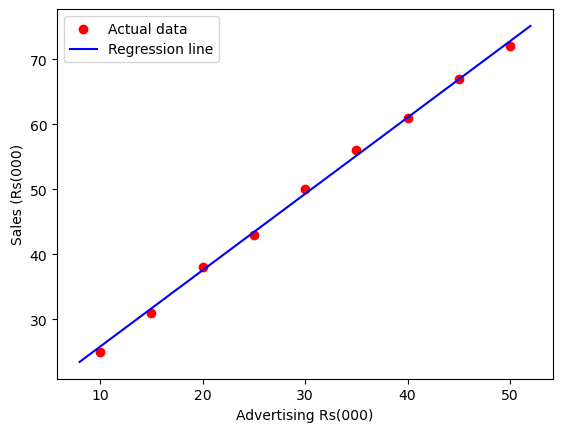

In [18]:
#plotting regression line

min_x = X.min().iloc[0] -2
max_x = X.max().iloc[0] + 2

x = np.linspace(min_x,max_x,1000)

y_line = model.coef_[0]*x +model.intercept_

plt.scatter(X,y,color='red',label='Actual data')
plt.plot(x,y_line,color='blue',label='Regression line')

plt.xlabel('Advertising Rs(000)')
plt.ylabel('Sales (Rs(000)')
plt.legend()
plt.show()

### Interpretation

The fitted regression line shows a strong positive relationship between advertising expenditure and sales. The upward slope indicates that higher advertising expenditure is associated with higher predicted sales.

The actual observations are compared with the fitted line to visually assess how closely the Linear Regression model represents the relationship in the test data.

## 5. Residual Analysis

Residuals represent the difference between the **actual sales values and the sales predicted by the Linear Regression model**.

A residual plot is used to examine whether the prediction errors show any systematic pattern.

### What to Look For

* Residuals should ideally be scattered randomly around the zero line.
* A clear curve or pattern may indicate that a linear model is not capturing the underlying relationship effectively.
* A relatively even spread of residuals suggests that the model errors are reasonably consistent across the range of predictions.


C:\Users\KIIT\AppData\Local\Temp\ipykernel_42736\2457783015.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


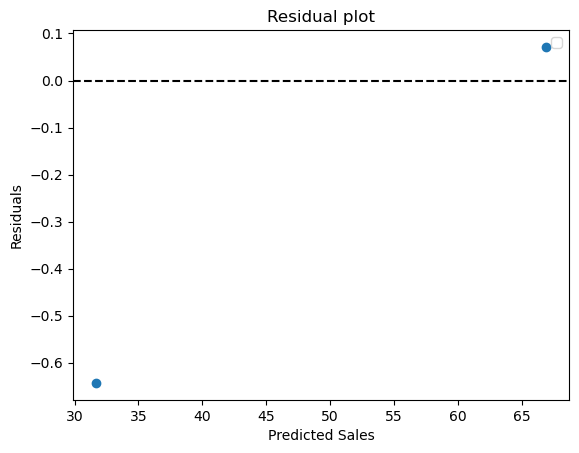

In [19]:
#residual = actual - pred-tells how wrong the model was
# ex actual y= 60 ,y_red =57, => residual = 3
residuals = y_test - y_pred
plt.scatter(y_pred,residuals) # tells how far it is from actual
plt.axhline(y=0,color='black',linestyle='--')

plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')

plt.legend()
plt.title('Residual plot')
plt.show()

### Residual Plot Interpretation

The residuals are examined around the zero reference line to assess whether systematic patterns are present. The plot provides an additional diagnostic for evaluating the suitability of the Linear Regression model beyond numerical metrics such as MAE, RMSE, and R².

Together with the high **R² score of approximately 0.9994**, the residual analysis provides evidence that the fitted model represents the relationship in this dataset very closely.


In [20]:
print("Mean residual:", residuals.mean())
print("MAE:", np.mean(np.abs(residuals)))

Mean residual: -0.2857142857142829
MAE: 0.35714285714286653


### Residual Analysis and MAE

The residual plot helps visualize the prediction errors, while Mean Absolute Error (MAE) provides a numerical measure of the average prediction error.

The model achieved an MAE of approximately **0.357**, meaning that the model's predictions differ from the actual sales values by about **0.357 sales units on average**, in absolute terms.

A lower MAE indicates smaller prediction errors. The MAE should be interpreted together with the residual plot and other evaluation metrics such as RMSE and R².

# 6. Conclusion

The analysis shows a strong positive relationship between advertising expenditure and sales in the given dataset.

A Linear Regression model was trained to predict sales from advertising expenditure and achieved an **R² score of approximately 0.9994** on the test set, indicating that the model explains most of the observed variation in sales within this dataset.

The model can therefore be used as a simple predictive tool for estimating expected sales based on advertising expenditure.

### Key Takeaways

* Advertising expenditure and sales show a strong positive relationship.
* Linear Regression provides an effective fit for this dataset.
* The model achieved an **R² of approximately 0.9994**.
* MAE, MSE, and RMSE were used to evaluate prediction error.
* Model coefficients were interpreted from a business perspective.
* The results describe an association in this dataset and should not be interpreted as evidence of causation.
